# Gutenberg Gait Database | Script to merge the data with GaitRec data 

In [19]:
# Copyright (C)  2021  Djordje Slijepcevic
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
# GNU General Public License for more details.
# 
# You should have received a copy of the GNU General Public License
# along with this program. If not, see <http://www.gnu.org/licenses/>.

### In order to use this notebook, please download the GaitRec dataset from: [GaitRec dataset](https://figshare.com/collections/GaitRec_A_large-scale_ground_reaction_force_dataset_of_healthy_and_impaired_gait/4788012)
### For futher information regarding the GaitRec dataset refer to: [GaitRec paper](https://www.nature.com/articles/s41597-020-0481-z)

In [20]:
import sys
print(sys.executable)

c:\Users\trist\OneDrive\Documenten\Project_Bewegingen_TriVik\.venv\Scripts\python.exe


In [21]:
import pandas as pd
import os
import numpy as np

### Utility functions

In [22]:
def add_dataset_id(data):
    # for the GaitRec data we will define the dataset ID as 0
    data['DATASET_ID'] = 0
    return data

def make_unique_id(data1, data2):
    # SUBJECT_ID and SESSION_ID of data2 are changed to ensure their uniqueness (by adding the
    # maximum ID to the IDs of the GaitRec dataset)
    
    max_id = np.max(data1['SUBJECT_ID'].values)
    data2['SUBJECT_ID'] = data2['SUBJECT_ID']+max_id
    
    max_id = np.max(data1['SESSION_ID'].values)
    data2['SESSION_ID'] = data2['SESSION_ID']+max_id
    
    return data2 

def merge_data(data1, data2):
    # prior to merging we need to add a DATASET_ID for data2 and change the
    # SUBJECT_ID and SESSION_ID to ensure their uniqueness
    
    data2 = add_dataset_id(data2)
    data2 = make_unique_id(data1,data2)
    data = pd.concat([data1, data2], ignore_index=True, sort=False)
    return data

### Gutenberg Gait Database

In [30]:
# Path to data
path = 'Walking Data/'

# Left lower extremity
GRF_F_V_PRO_left = pd.read_csv(os.path.join(path,'GRF_F_V_PRO_left.csv'))
# GRF_F_V_RAW_left = pd.read_csv(os.path.join(path,'GRF_F_V_RAW_left.csv'))

GRF_F_AP_PRO_left = pd.read_csv(os.path.join(path,'GRF_F_AP_PRO_left.csv'))
# GRF_F_AP_RAW_left = pd.read_csv(os.path.join(path,'GRF_F_AP_RAW_left.csv'))

# Walking Speed
GRF_walking_speed = pd.read_csv(os.path.join(path,'GRF_walking_speed.csv'))

'''GRF_F_ML_PRO_left = pd.read_csv(os.path.join(path,'GRF_F_ML_PRO_left.csv'))
GRF_F_ML_RAW_left = pd.read_csv(os.path.join(path,'GRF_F_ML_RAW_left.csv'))

GRF_COP_AP_PRO_left = pd.read_csv(os.path.join(path,'GRF_COP_AP_PRO_left.csv'))
GRF_COP_AP_RAW_left = pd.read_csv(os.path.join(path,'GRF_COP_AP_RAW_left.csv'))

GRF_COP_ML_PRO_left = pd.read_csv(os.path.join(path,'GRF_COP_ML_PRO_left.csv'))
GRF_COP_ML_RAW_left = pd.read_csv(os.path.join(path,'GRF_COP_ML_RAW_left.csv'))

# Right lower extremity
GRF_F_V_PRO_right = pd.read_csv(os.path.join(path,'GRF_F_V_PRO_right.csv'))
GRF_F_V_RAW_right = pd.read_csv(os.path.join(path,'GRF_F_V_RAW_right.csv'))

GRF_F_AP_PRO_right = pd.read_csv(os.path.join(path,'GRF_F_AP_PRO_right.csv'))
GRF_F_AP_RAW_right = pd.read_csv(os.path.join(path,'GRF_F_AP_RAW_right.csv'))

GRF_F_ML_PRO_right = pd.read_csv(os.path.join(path,'GRF_F_ML_PRO_right.csv'))
GRF_F_ML_RAW_right = pd.read_csv(os.path.join(path,'GRF_F_ML_RAW_right.csv'))

GRF_COP_AP_PRO_right = pd.read_csv(os.path.join(path,'GRF_COP_AP_PRO_right.csv'))
GRF_COP_AP_RAW_right = pd.read_csv(os.path.join(path,'GRF_COP_AP_RAW_right.csv'))

GRF_COP_ML_PRO_right = pd.read_csv(os.path.join(path,'GRF_COP_ML_PRO_right.csv'))
GRF_COP_ML_RAW_right = pd.read_csv(os.path.join(path,'GRF_COP_ML_RAW_right.csv'))

Walking Speed
GRF_walking_speed = pd.read_csv(os.path.join(path,'GRF_walking_speed.csv')) 

# Metadata
GRF_metadata = pd.read_csv(os.path.join(path,'GRF_metadata.csv'))'''


"GRF_F_ML_PRO_left = pd.read_csv(os.path.join(path,'GRF_F_ML_PRO_left.csv'))\nGRF_F_ML_RAW_left = pd.read_csv(os.path.join(path,'GRF_F_ML_RAW_left.csv'))\n\nGRF_COP_AP_PRO_left = pd.read_csv(os.path.join(path,'GRF_COP_AP_PRO_left.csv'))\nGRF_COP_AP_RAW_left = pd.read_csv(os.path.join(path,'GRF_COP_AP_RAW_left.csv'))\n\nGRF_COP_ML_PRO_left = pd.read_csv(os.path.join(path,'GRF_COP_ML_PRO_left.csv'))\nGRF_COP_ML_RAW_left = pd.read_csv(os.path.join(path,'GRF_COP_ML_RAW_left.csv'))\n\n# Right lower extremity\nGRF_F_V_PRO_right = pd.read_csv(os.path.join(path,'GRF_F_V_PRO_right.csv'))\nGRF_F_V_RAW_right = pd.read_csv(os.path.join(path,'GRF_F_V_RAW_right.csv'))\n\nGRF_F_AP_PRO_right = pd.read_csv(os.path.join(path,'GRF_F_AP_PRO_right.csv'))\nGRF_F_AP_RAW_right = pd.read_csv(os.path.join(path,'GRF_F_AP_RAW_right.csv'))\n\nGRF_F_ML_PRO_right = pd.read_csv(os.path.join(path,'GRF_F_ML_PRO_right.csv'))\nGRF_F_ML_RAW_right = pd.read_csv(os.path.join(path,'GRF_F_ML_RAW_right.csv'))\n\nGRF_COP_AP_PRO

### GaitRec Dataset

In [24]:
'''# Path to data
path = 'GaitRec/'

# Left lower extremity
GRF_F_V_PRO_left = merge_data(GRF_F_V_PRO_left, pd.read_csv(os.path.join(path,'GRF_F_V_PRO_left.csv')))
GRF_F_V_RAW_left = merge_data(GRF_F_V_RAW_left, pd.read_csv(os.path.join(path,'GRF_F_V_RAW_left.csv')))

GRF_F_AP_PRO_left = merge_data(GRF_F_AP_PRO_left, pd.read_csv(os.path.join(path,'GRF_F_AP_PRO_left.csv')))
GRF_F_AP_RAW_left = merge_data(GRF_F_AP_RAW_left, pd.read_csv(os.path.join(path,'GRF_F_AP_RAW_left.csv')))

GRF_F_ML_PRO_left = merge_data(GRF_F_ML_PRO_left, pd.read_csv(os.path.join(path,'GRF_F_ML_PRO_left.csv')))
GRF_F_ML_RAW_left = merge_data(GRF_F_ML_RAW_left, pd.read_csv(os.path.join(path,'GRF_F_ML_RAW_left.csv')))

GRF_COP_AP_PRO_left = merge_data(GRF_COP_AP_PRO_left, pd.read_csv(os.path.join(path,'GRF_COP_AP_PRO_left.csv')))
GRF_COP_AP_RAW_left = merge_data(GRF_COP_AP_RAW_left, pd.read_csv(os.path.join(path,'GRF_COP_AP_RAW_left.csv')))

GRF_COP_ML_PRO_left = merge_data(GRF_COP_ML_PRO_left, pd.read_csv(os.path.join(path,'GRF_COP_ML_PRO_left.csv')))
GRF_COP_ML_RAW_left = merge_data(GRF_COP_ML_RAW_left, pd.read_csv(os.path.join(path,'GRF_COP_ML_RAW_left.csv')))

# Right lower extremity
GRF_F_V_PRO_right = merge_data(GRF_F_V_PRO_right, pd.read_csv(os.path.join(path,'GRF_F_V_PRO_right.csv')))
GRF_F_V_RAW_right = merge_data(GRF_F_V_RAW_right, pd.read_csv(os.path.join(path,'GRF_F_V_RAW_right.csv')))

GRF_F_AP_PRO_right = merge_data(GRF_F_AP_PRO_right, pd.read_csv(os.path.join(path,'GRF_F_AP_PRO_right.csv')))
GRF_F_AP_RAW_right = merge_data(GRF_F_AP_RAW_right, pd.read_csv(os.path.join(path,'GRF_F_AP_RAW_right.csv')))

GRF_F_ML_PRO_right = merge_data(GRF_F_ML_PRO_right, pd.read_csv(os.path.join(path,'GRF_F_ML_PRO_right.csv')))
GRF_F_ML_RAW_right = merge_data(GRF_F_ML_RAW_right, pd.read_csv(os.path.join(path,'GRF_F_ML_RAW_right.csv')))

GRF_COP_AP_PRO_right = merge_data(GRF_COP_AP_PRO_right, pd.read_csv(os.path.join(path,'GRF_COP_AP_PRO_right.csv')))
GRF_COP_AP_RAW_right = merge_data(GRF_COP_AP_RAW_right, pd.read_csv(os.path.join(path,'GRF_COP_AP_RAW_right.csv')))

GRF_COP_ML_PRO_right = merge_data(GRF_COP_ML_PRO_right, pd.read_csv(os.path.join(path,'GRF_COP_ML_PRO_right.csv')))
GRF_COP_ML_RAW_right = merge_data(GRF_COP_ML_RAW_right, pd.read_csv(os.path.join(path,'GRF_COP_ML_RAW_right.csv')))


# Walking Speed: is not specified for GaitRec dataset (we will add NaNs for the GaitRec data)
GRF_walking_speed = merge_data(GRF_walking_speed, pd.read_csv(os.path.join(path,'GRF_F_V_PRO_left.csv')).iloc[:,0:3])

# Metadata
GRF_metadata = merge_data(GRF_metadata, pd.read_csv(os.path.join(path,'GRF_metadata.csv')))'''


"# Path to data\npath = 'GaitRec/'\n\n# Left lower extremity\nGRF_F_V_PRO_left = merge_data(GRF_F_V_PRO_left, pd.read_csv(os.path.join(path,'GRF_F_V_PRO_left.csv')))\nGRF_F_V_RAW_left = merge_data(GRF_F_V_RAW_left, pd.read_csv(os.path.join(path,'GRF_F_V_RAW_left.csv')))\n\nGRF_F_AP_PRO_left = merge_data(GRF_F_AP_PRO_left, pd.read_csv(os.path.join(path,'GRF_F_AP_PRO_left.csv')))\nGRF_F_AP_RAW_left = merge_data(GRF_F_AP_RAW_left, pd.read_csv(os.path.join(path,'GRF_F_AP_RAW_left.csv')))\n\nGRF_F_ML_PRO_left = merge_data(GRF_F_ML_PRO_left, pd.read_csv(os.path.join(path,'GRF_F_ML_PRO_left.csv')))\nGRF_F_ML_RAW_left = merge_data(GRF_F_ML_RAW_left, pd.read_csv(os.path.join(path,'GRF_F_ML_RAW_left.csv')))\n\nGRF_COP_AP_PRO_left = merge_data(GRF_COP_AP_PRO_left, pd.read_csv(os.path.join(path,'GRF_COP_AP_PRO_left.csv')))\nGRF_COP_AP_RAW_left = merge_data(GRF_COP_AP_RAW_left, pd.read_csv(os.path.join(path,'GRF_COP_AP_RAW_left.csv')))\n\nGRF_COP_ML_PRO_left = merge_data(GRF_COP_ML_PRO_left, pd.rea

## Processed Data

### Left Lower Extremity

In [25]:
GRF_F_V_PRO_left


,SUBJECT_ID,SESSION_ID,TRIAL_ID,F_V_PRO_1,F_V_PRO_2,F_V_PRO_3,F_V_PRO_4,F_V_PRO_5,F_V_PRO_6,F_V_PRO_7,...,F_V_PRO_92,F_V_PRO_93,F_V_PRO_94,F_V_PRO_95,F_V_PRO_96,F_V_PRO_97,F_V_PRO_98,F_V_PRO_99,F_V_PRO_100,F_V_PRO_101
0,510,413,1,0.022633,0.061113,0.114901,0.176286,0.240173,0.307632,0.381910,...,0.439735,0.363369,0.293813,0.233255,0.181122,0.135943,0.097352,0.065702,0.041022,0.022629
1,510,413,2,0.022631,0.064086,0.120122,0.182163,0.247071,0.318845,0.401557,...,0.410254,0.339074,0.275394,0.220207,0.172339,0.130209,0.093530,0.063213,0.039767,0.022631
2,510,413,3,0.022629,0.057981,0.105291,0.159700,0.219181,0.285077,0.358567,...,0.433426,0.360247,0.294009,0.235680,0.184456,0.139032,0.099369,0.066516,0.041136,0.022629
3,510,413,4,0.022627,0.065699,0.128061,0.203220,0.286525,0.377700,0.476686,...,0.413362,0.342532,0.279180,0.223987,0.175465,0.132305,0.094839,0.064081,0.040264,0.022632
4,510,413,6,0.022627,0.065287,0.124876,0.192132,0.262683,0.339977,0.428425,...,0.463430,0.387153,0.316935,0.254497,0.199263,0.149953,0.106697,0.070753,0.042899,0.022628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75727,93,999910375,6,0.037266,0.124201,0.254116,0.413485,0.568425,0.680740,0.753465,...,0.782086,0.728539,0.658133,0.573251,0.475792,0.370088,0.264481,0.169161,0.092006,0.037293
75728,93,999910375,7,0.037280,0.122560,0.249392,0.403474,0.549870,0.662797,0.745495,...,0.736363,0.638486,0.531009,0.420026,0.313949,0.220124,0.146514,0.094626,0.059892,0.037273
75729,93,999910375,9,0.037267,0.119322,0.239715,0.382490,0.508558,0.598377,0.650594,...,0.827001,0.727481,0.615522,0.496422,0.377286,0.267428,0.174353,0.107628,0.063829,0.037268
75730,93,999910375,10,0.037277,0.123184,0.251270,0.407886,0.560943,0.679554,0.763905,...,0.707498,0.603483,0.492429,0.382474,0.281612,0.196030,0.131851,0.087253,0.057363,0.037265


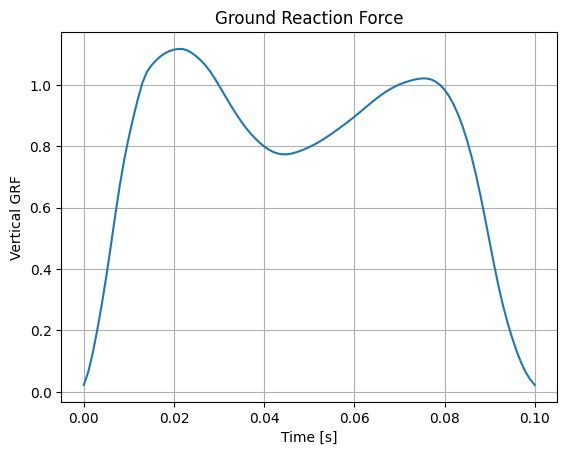

In [26]:
row_y = GRF_F_V_PRO_left.iloc[3]

force_y = row_y.filter(like="F_V_PRO").values

import numpy as np

n_points = 101
T = 0.1  # assume 1 second (you can scale later)

t = np.linspace(0, T, n_points)

import matplotlib.pyplot as plt

plt.plot(t, force_y)
plt.xlabel("Time [s]")
plt.ylabel("Vertical GRF")
plt.title("Ground Reaction Force")
plt.grid()
plt.show()

In [27]:
GRF_F_AP_PRO_left

,SUBJECT_ID,SESSION_ID,TRIAL_ID,F_AP_PRO_1,F_AP_PRO_2,F_AP_PRO_3,F_AP_PRO_4,F_AP_PRO_5,F_AP_PRO_6,F_AP_PRO_7,...,F_AP_PRO_92,F_AP_PRO_93,F_AP_PRO_94,F_AP_PRO_95,F_AP_PRO_96,F_AP_PRO_97,F_AP_PRO_98,F_AP_PRO_99,F_AP_PRO_100,F_AP_PRO_101
0,510,413,1,-0.000670,0.004931,0.010735,0.007857,-0.006622,-0.027174,-0.048088,...,0.096395,0.081169,0.064288,0.048071,0.034576,0.024142,0.015432,0.007100,-0.000426,-0.005152
1,510,413,2,0.008001,0.019121,0.026793,0.021513,0.003647,-0.018999,-0.040842,...,0.093676,0.078346,0.062120,0.046927,0.034311,0.024450,0.016102,0.008016,0.000419,-0.004925
2,510,413,3,0.004010,0.010528,0.014719,0.009974,-0.004298,-0.023603,-0.043511,...,0.102955,0.086728,0.069173,0.052592,0.038667,0.027473,0.017748,0.008439,0.000184,-0.005014
3,510,413,4,0.002082,0.008213,0.012272,0.005936,-0.013060,-0.038867,-0.064183,...,0.102953,0.085782,0.067937,0.051657,0.038363,0.027743,0.018289,0.009041,0.000805,-0.004549
4,510,413,6,0.007449,0.017501,0.023836,0.016122,-0.005822,-0.033894,-0.061242,...,0.108590,0.092894,0.074780,0.056742,0.041161,0.028754,0.018503,0.009227,0.001187,-0.004078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75727,93,999910375,6,-0.002277,-0.011149,-0.025474,-0.045102,-0.068212,-0.090864,-0.109366,...,0.297626,0.297107,0.289089,0.272191,0.244945,0.207222,0.160169,0.110690,0.065460,0.030105
75728,93,999910375,7,-0.004916,-0.016063,-0.032619,-0.053308,-0.074799,-0.093741,-0.109454,...,0.303708,0.285449,0.256591,0.216366,0.169070,0.119166,0.072832,0.035154,0.007860,-0.008754
75729,93,999910375,9,-0.005907,-0.015807,-0.029809,-0.046288,-0.061370,-0.072528,-0.079323,...,0.311722,0.296527,0.270824,0.235261,0.190255,0.140384,0.091022,0.048999,0.017060,-0.004156
75730,93,999910375,10,0.001317,-0.002827,-0.010815,-0.023744,-0.042220,-0.064731,-0.087459,...,0.293551,0.271288,0.238564,0.196318,0.148692,0.100352,0.057590,0.024286,0.001321,-0.011746


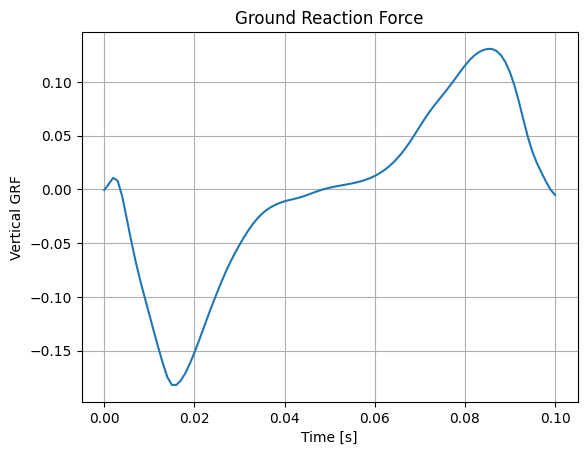

In [28]:
row_x = GRF_F_AP_PRO_left.iloc[0]

force_x = row_x.filter(like="F_AP_PRO").values

import numpy as np

n_points = 101
T = 0.1  # assume 1 second (you can scale later)

t = np.linspace(0, T, n_points)

import matplotlib.pyplot as plt

plt.plot(t, force_x)
plt.xlabel("Time [s]")
plt.ylabel("Vertical GRF")
plt.title("Ground Reaction Force")
plt.grid()
plt.show()

In [29]:
GRF_F_ML_PRO_left

NameError: name 'GRF_F_ML_PRO_left' is not defined

In [ ]:
GRF_COP_AP_PRO_left

In [ ]:
GRF_COP_ML_PRO_left

### Right Lower Extremity

In [ ]:
GRF_F_V_PRO_right

In [ ]:
GRF_F_AP_PRO_right

In [ ]:
GRF_F_ML_PRO_right

In [ ]:
GRF_COP_AP_PRO_right

In [ ]:
GRF_COP_ML_PRO_right

## Raw Data

### Left Lower Extremity


In [ ]:
GRF_F_V_RAW_left

,SUBJECT_ID,SESSION_ID,TRIAL_ID,F_V_RAW_1,F_V_RAW_2,F_V_RAW_3,F_V_RAW_4,F_V_RAW_5,F_V_RAW_6,F_V_RAW_7,...,F_V_RAW_410,F_V_RAW_411,F_V_RAW_412,F_V_RAW_413,F_V_RAW_414,F_V_RAW_415,F_V_RAW_416,F_V_RAW_417,F_V_RAW_418,F_V_RAW_419
0,510,413,1,25.007842,44.399398,71.282930,111.350325,151.060614,188.434204,223.103463,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,510,413,2,25.019307,62.278721,94.491200,133.914834,176.045690,211.082598,241.765517,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,510,413,3,25.021281,51.954258,74.954363,106.561071,141.265769,172.779614,202.292505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,510,413,4,25.024699,57.128230,91.755101,132.413711,178.811880,224.234218,268.680726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,510,413,6,25.020170,63.753965,100.386720,144.404215,190.093214,229.451770,263.502418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75727,93,999910375,6,25.000883,162.156094,540.383222,524.419022,504.165056,502.675160,521.930833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75728,93,999910375,7,25.027186,168.908101,493.128975,459.407466,469.055287,495.140246,514.900488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75729,93,999910375,9,25.079282,137.062149,426.693392,417.670851,413.300824,434.787539,450.887809,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75730,93,999910375,10,25.007390,214.546408,464.193761,504.907755,516.060309,503.423246,515.735626,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
GRF_F_AP_RAW_left

In [ ]:
GRF_F_ML_RAW_left

In [ ]:
GRF_COP_AP_RAW_left

In [ ]:
GRF_COP_ML_RAW_left

### Right Lower Extremity

In [ ]:
GRF_F_V_RAW_right

In [ ]:
GRF_F_AP_RAW_right

In [ ]:
GRF_F_ML_RAW_right

In [ ]:
GRF_COP_AP_RAW_right

In [ ]:
GRF_COP_ML_RAW_right

## Walking speed

In [35]:
GRF_walking_speed


,DATASET_ID,SUBJECT_ID,SESSION_ID,TRIAL_ID,WALKING_SPEED
0,1,1,1,1,1.62
1,1,1,1,2,1.65
2,1,1,1,3,1.64
3,1,1,1,4,1.68
4,1,1,1,5,1.67
...,...,...,...,...,...
8814,10,350,661,4,NaN
8815,10,350,661,5,NaN
8816,10,350,661,6,NaN
8817,10,350,661,7,NaN


## Metadata

In [ ]:
GRF_metadata